In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=pd.read_excel('https://robertohincapie.com/data/datos_viviendas1.xlsx')
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato
0,11318-M3058418,Castropol/Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0
1,11318-M3021864,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0
3,13155-M3070155,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0
4,2364-M3070004,El Tesoro,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0


In [18]:
data=data.drop('Valor_Admon', axis=1)
data.info() #Es para ver las condiciones que tienen los datos
#dado que la administración hay tantos valores nulos, se elimina la columna.
#la columna de estrato, el valor faltante, esperemos


<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cod_Inmueble     93 non-null     str    
 1   Barrio           93 non-null     str    
 2   Precio           93 non-null     int64  
 3   Antiguedad       93 non-null     str    
 4   Area_Construida  93 non-null     float64
 5   Area_Privada     93 non-null     float64
 6   Parqueaderos     93 non-null     int64  
 7   Habitaciones     93 non-null     int64  
 8   Baños            93 non-null     int64  
 9   Estrato          92 non-null     float64
dtypes: float64(3), int64(4), str(3)
memory usage: 11.1 KB


In [19]:
#Vamos a corregir el estrato del inmueble faltante por un valor de 6 por ser del poblado.
data.loc[data['Cod_Inmueble']=='12133-1406' , 'Estrato']=6
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cod_Inmueble     93 non-null     str    
 1   Barrio           93 non-null     str    
 2   Precio           93 non-null     int64  
 3   Antiguedad       93 non-null     str    
 4   Area_Construida  93 non-null     float64
 5   Area_Privada     93 non-null     float64
 6   Parqueaderos     93 non-null     int64  
 7   Habitaciones     93 non-null     int64  
 8   Baños            93 non-null     int64  
 9   Estrato          93 non-null     float64
dtypes: float64(3), int64(4), str(3)
memory usage: 11.1 KB


In [20]:
data.describe()

,Precio,Area_Construida,Area_Privada,Parqueaderos,Habitaciones,Baños,Estrato
count,9.300000e+01,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,7.267226e+08,150.789785,151.563978,1.838710,3.010753,3.172043,5.462366
std,3.645851e+08,80.822469,82.019318,0.875889,0.683575,1.049054,0.866767
min,1.760000e+08,32.000000,32.000000,0.000000,1.000000,1.000000,1.000000
25%,4.600000e+08,98.000000,98.000000,1.000000,3.000000,2.000000,5.000000
50%,7.000000e+08,136.000000,136.000000,2.000000,3.000000,3.000000,6.000000
75%,8.800000e+08,184.000000,184.000000,2.000000,3.000000,4.000000,6.000000
max,2.050000e+09,425.000000,425.000000,4.000000,5.000000,5.000000,6.000000


In [21]:
#Eliminamos la columna de codigo de inmueble pues es un índice y no aporta información
#Eliminamos el área construida, pues su valor es casi el mismo del área privada
data=data.drop(['Cod_Inmueble','Area_Construida'], axis=1)
data.head()

,Barrio,Precio,Antiguedad,Area_Privada,Parqueaderos,Habitaciones,Baños,Estrato
0,Castropol/Poblado,518000000,Entre 0 y 5 años,122.0,1,4,3,6.0
1,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,1,2,3,5.0
2,Laureles,845000000,Entre 0 y 5 años,137.0,2,3,4,5.0
3,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,2,3,2,6.0
4,El Tesoro,1250000000,Remodelado,232.0,2,3,5,6.0


In [22]:
data['Barrio']=data['Barrio'].replace({'Castropol/Poblado':'Poblado','Belen/Malibu':'Belén','Laureles':'Laureles','EL POBLADO DE SANTA MARIA DE LOS ANGELES':'Poblado',
'El Tesoro':'Poblado','san Germán':'Robledo','EL TESORO':'Poblado','EL PESEBRE':'Robledo','EL POBLADO':'Poblado','Conquistadores':'Conquistadores',
'LOS BALSOS':'Poblado','La Calera':'Poblado','Calasanz':'Calasanz','BELEN RODEO ALTO':'Belén','El Poblado':'Poblado','Castropol':'Poblado',
'Ciudad Del Río':'Poblado','poblado':'Poblado','La Candelaria':'Centro', 'Loma De Los Bernal':'Belén', 'LA LINDE':'Poblado',
'San Lucas':'Poblado', 'Los Balsos':'Poblado', 'La Pilarica':'Robledo', 'CAMPESTRE':'Poblado', 'Poblado':'Poblado','ALTOS DEL POBLADO':'Poblado',
'lalinde':'Poblado','Balsos':'Poblado', 'LA FLORIDA':'Poblado','LOS BALSOS NO 1':'Poblado', 'Las Palmas':'Poblado', 'Loma del Indio':'Poblado',
'POBLADO LA FRONTERA':'Poblado', 'Conquistadores/occidente':'Conquistadores', 'Los Parra':'Poblado','Belen':'Belén', 'Medellín':'Medellín',
'Los colores':'Los Colores', 'Sabaneta':'Sabaneta','EL POBLADO LA LINDE':'Poblado', 'Los Balsos - El Poblado':'Poblado', 'LA AMERICA':'La América',
'Santa Maria De Los':'Poblado', 'LAURELES':'Laureles'})
data['Barrio'].unique()

<ArrowStringArray>
[       'Poblado',          'Belén',       'Laureles',        'Robledo',
 'Conquistadores',       'Calasanz',         'Centro',       'Medellín',
    'Los Colores',       'Sabaneta',     'La América']
Length: 11, dtype: str

In [23]:
data['Antiguedad'].unique()

<ArrowStringArray>
[  'Entre 0 y 5 años',         'Remodelado', 'Entre 10 y 20 años',
  'Entre 5 y 10 años',     'Más de 20 años']
Length: 5, dtype: str

In [24]:
#Variables dummies y codificadas:
data = pd.get_dummies(data, columns=['Barrio'], drop_first=False)
data['Antiguedad']=data['Antiguedad'].replace({
    'Entre 0 y 5 años':0,
    'Entre 5 y 10 años':1,
    'Entre 10 y 20 años':2,
    'Más de 20 años':3,
    'Remodelado':4
})
data.head()


,Precio,Antiguedad,Area_Privada,Parqueaderos,Habitaciones,Baños,Estrato,Barrio_Belén,Barrio_Calasanz,Barrio_Centro,Barrio_Conquistadores,Barrio_La América,Barrio_Laureles,Barrio_Los Colores,Barrio_Medellín,Barrio_Poblado,Barrio_Robledo,Barrio_Sabaneta
0,518000000,0,122.0,1,4,3,6.0,False,False,False,False,False,False,False,False,True,False,False
1,382000000,0,64.0,1,2,3,5.0,True,False,False,False,False,False,False,False,False,False,False
2,845000000,0,137.0,2,3,4,5.0,False,False,False,False,False,True,False,False,False,False,False
3,705000000,0,123.0,2,3,2,6.0,False,False,False,False,False,False,False,False,True,False,False
4,1250000000,4,232.0,2,3,5,6.0,False,False,False,False,False,False,False,False,True,False,False


In [25]:
X=data.drop('Precio', axis=1)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Antiguedad             93 non-null     object 
 1   Area_Privada           93 non-null     float64
 2   Parqueaderos           93 non-null     int64  
 3   Habitaciones           93 non-null     int64  
 4   Baños                  93 non-null     int64  
 5   Estrato                93 non-null     float64
 6   Barrio_Belén           93 non-null     bool   
 7   Barrio_Calasanz        93 non-null     bool   
 8   Barrio_Centro          93 non-null     bool   
 9   Barrio_Conquistadores  93 non-null     bool   
 10  Barrio_La América      93 non-null     bool   
 11  Barrio_Laureles        93 non-null     bool   
 12  Barrio_Los Colores     93 non-null     bool   
 13  Barrio_Medellín        93 non-null     bool   
 14  Barrio_Poblado         93 non-null     bool   
 15  Barrio_Robledo     

In [26]:
X.var()


Antiguedad                  1.486209
Area_Privada             6727.168498
Parqueaderos                0.767181
Habitaciones                0.467274
Baños                       1.100514
Estrato                     0.751286
Barrio_Belén                0.041608
Barrio_Calasanz             0.010753
Barrio_Centro               0.010753
Barrio_Conquistadores       0.031557
Barrio_La América           0.010753
Barrio_Laureles             0.105423
Barrio_Los Colores          0.010753
Barrio_Medellín             0.010753
Barrio_Poblado              0.212716
Barrio_Robledo              0.031557
Barrio_Sabaneta             0.021272
dtype: object

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xnorm=scaler.fit_transform(X)
Xnorm=pd.DataFrame(data=Xnorm, columns=X.columns)
Xnorm.head()

,Antiguedad,Area_Privada,Parqueaderos,Habitaciones,Baños,Estrato,Barrio_Belén,Barrio_Calasanz,Barrio_Centro,Barrio_Conquistadores,Barrio_La América,Barrio_Laureles,Barrio_Los Colores,Barrio_Medellín,Barrio_Poblado,Barrio_Robledo,Barrio_Sabaneta
0,-1.055290,-0.362405,-0.962743,1.455012,-0.164887,0.623637,-0.212000,-0.104257,-0.104257,-0.182574,-0.104257,-0.366260,-0.104257,-0.104257,0.656330,-0.182574,-0.14825
1,-1.055290,-1.073388,-0.962743,-1.486642,-0.164887,-0.536328,4.716991,-0.104257,-0.104257,-0.182574,-0.104257,-0.366260,-0.104257,-0.104257,-1.523624,-0.182574,-0.14825
2,-1.055290,-0.178530,0.185143,-0.015815,0.793519,-0.536328,-0.212000,-0.104257,-0.104257,-0.182574,-0.104257,2.730301,-0.104257,-0.104257,-1.523624,-0.182574,-0.14825
3,-1.055290,-0.350147,0.185143,-0.015815,-1.123294,0.623637,-0.212000,-0.104257,-0.104257,-0.182574,-0.104257,-0.366260,-0.104257,-0.104257,0.656330,-0.182574,-0.14825
4,2.243599,0.986012,0.185143,-0.015815,1.751926,0.623637,-0.212000,-0.104257,-0.104257,-0.182574,-0.104257,-0.366260,-0.104257,-0.104257,0.656330,-0.182574,-0.14825


In [28]:
#PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(Xnorm.values) #Esto calcula la matriz de covarianza y los vectores propios de la matriz
Y=pca.transform(Xnorm.values)
Y=pd.DataFrame(Y, columns=['PC_'+str(i) for i in range(1,len(Xnorm.columns)+1)])


Y.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17
0,0.518697,-0.496586,0.241077,-0.649531,-0.458524,0.030343,-0.018188,0.035198,-0.072946,-0.026619,-0.285772,-0.494264,-1.913036,-0.450847,-0.038925,0.230223,4.693050e-16
1,-2.664534,-1.050835,1.014509,2.176279,0.670213,3.188829,1.038123,0.958906,-0.126982,-0.507393,-1.782514,-0.052375,0.084489,0.160178,0.285350,0.643319,1.288094e-15
2,-0.440612,1.528510,2.767667,-0.403025,0.172322,0.371674,-0.585449,-0.156705,0.249901,-0.030389,0.392110,-0.236651,0.665771,0.106119,-0.184256,0.641592,-9.323516e-16
3,0.110169,-1.230067,0.150835,-0.399942,-0.062377,0.062762,-0.160584,0.021214,-0.043924,0.011532,0.188528,-0.990514,-0.566868,-0.049201,0.011330,-0.767948,1.362381e-16
4,1.791882,0.487757,-1.328227,0.570486,-0.153420,-0.039987,0.083297,-0.067206,0.108210,-0.023791,0.544194,1.738925,0.659654,0.079767,0.384176,0.868989,-3.633623e-16


In [35]:
for val, cod in zip(pca.components_[-1], Xnorm.columns):
  print(cod, val)

Antiguedad -9.76360579478204e-17
Area_Privada -2.1374491847658535e-16
Parqueaderos -1.4242138519441147e-16
Habitaciones 1.0435925444745782e-16
Baños 4.9325060116736506e-17
Estrato 1.9983325737192632e-17
Barrio_Belén 0.2890814333667435
Barrio_Calasanz 0.14695660628721452
Barrio_Centro 0.1469566062872146
Barrio_Conquistadores 0.2517544074890069
Barrio_La América 0.14695660628721446
Barrio_Laureles 0.4601489858750941
Barrio_Los Colores 0.14695660628721455
Barrio_Medellín 0.14695660628721455
Barrio_Poblado 0.6536283706727826
Barrio_Robledo 0.25175440748900707
Barrio_Sabaneta 0.20669543946307964


In [30]:
np.cumsum(pca.explained_variance_ratio_)

array([0.23327083, 0.32883732, 0.41100056, 0.47765625, 0.54130873,
       0.60242266, 0.66334398, 0.72340602, 0.7830333 , 0.84258848,
       0.88955019, 0.93287475, 0.96261987, 0.97819859, 0.9896268 ,
       1.        , 1.        ])

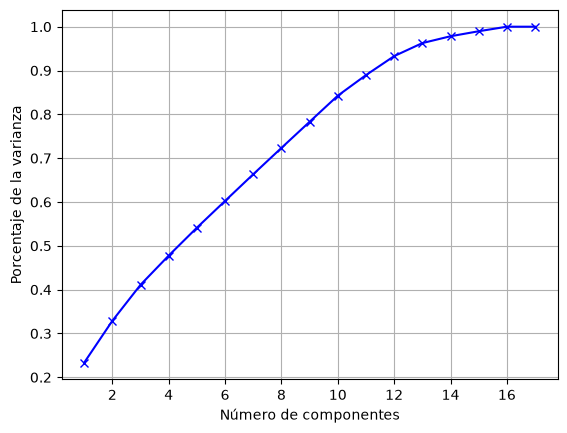

In [31]:
plt.plot(range(1,len(Xnorm.columns)+1), np.cumsum(pca.explained_variance_ratio_),'x-b')
plt.xlabel('Número de componentes')
plt.ylabel('Porcentaje de la varianza')
plt.grid()

In [32]:
data=pd.read_excel('https://robertohincapie.com/data/datos_viviendas2.xlsx')
data.info()

#Realice usted para los siguientes datos, la representación por medio de PCA, y determine el número de componentes que expliquen el 90% de la varianza.

<class 'pandas.DataFrame'>
RangeIndex: 8921 entries, 0 to 8920
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Antigüedad       8921 non-null   str    
 1   Estrato          8741 non-null   float64
 2   Habitaciones     8921 non-null   int64  
 3   Parqueaderos     8921 non-null   int64  
 4   Precio           8921 non-null   int64  
 5   Administración   6307 non-null   float64
 6   Arriendo         518 non-null    float64
 7   Área construida  8921 non-null   int64  
 8   Baños            8921 non-null   int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 674.8 KB
